# MLP and LTSM Training


In [3]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import json

# path to processed data
data_processed_folder = "/content/drive/MyDrive/CS171_Police_Call_Project/data_processed"

# Project folder must be assigned to store the trained Models, history and generated images
project_folder = "/content/drive/MyDrive/CS171_Police_Call_Project"

# Set a seed for reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

# set the seed for keras
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

!ls $data_processed_folder

candidate_features.json        test_unscaled.csv
final_split_audit.csv	       train_scaled.csv
model_ready_hourly.csv	       train_unscaled.csv
numerical_preprocessor.joblib  validation_scaled.csv
preprocessing_metadata.json    validation_unscaled.csv
test_scaled.csv


In [5]:
# import the train, validation and test data
train_df = pd.read_csv(os.path.join(data_processed_folder, "train_scaled.csv"))
val_df = pd.read_csv(os.path.join(data_processed_folder, "validation_scaled.csv"))
test_df = pd.read_csv(os.path.join(data_processed_folder, "test_scaled.csv"))


with open(os.path.join(data_processed_folder, "candidate_features.json"), "r") as f:
    feature_names = json.load(f)

target_col = "NEXT_HOUR_CALLS"

# Print to verify the data

print(f'Total Features: {len(feature_names)}')
print(f'Feature Names: {feature_names}')

X_train = train_df[feature_names]
y_train = train_df[target_col]

X_val = val_df[feature_names]
y_val = val_df[target_col]

X_test = test_df[feature_names]
y_test = test_df[target_col]

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape  : {X_val.shape}   | y_val shape  : {y_val.shape}")
print(f"X_test shape  : {X_test.shape}   | y_test shape  : {y_test.shape}")



Total Features: 48
Feature Names: ['TARGET_HOUR', 'TARGET_DAY_OF_WEEK', 'TARGET_MONTH', 'TARGET_IS_WEEKEND', 'HOUR_SIN', 'HOUR_COS', 'DAY_OF_WEEK_SIN', 'DAY_OF_WEEK_COS', 'MONTH_SIN', 'MONTH_COS', 'LAG_1H', 'LAG_2H', 'LAG_3H', 'LAG_24H', 'LAG_48H', 'LAG_168H', 'ROLLING_MEAN_3H', 'ROLLING_MEAN_6H', 'ROLLING_MEAN_24H', 'ROLLING_MEAN_168H', 'CURRENT_PRIORITY_1_COUNT', 'CURRENT_PRIORITY_2_COUNT', 'CURRENT_PRIORITY_3_COUNT', 'CURRENT_PRIORITY_4_COUNT', 'CURRENT_PRIORITY_5_COUNT', 'CURRENT_PRIORITY_6_COUNT', 'CURRENT_PRIORITY_OTHER_COUNT', 'CURRENT_CALLTYPE_VEHICLE_STOP_COUNT', 'CURRENT_CALLTYPE_DISTURBANCE_COUNT', 'CURRENT_CALLTYPE_WELFARE_CHECK_COUNT', 'CURRENT_CALLTYPE_ALARM_AUDIBLE_COUNT', 'CURRENT_CALLTYPE_PARKING_VIOLATION_COUNT', 'CURRENT_CALLTYPE_DISTURBANCE_MUSIC_COUNT', 'CURRENT_CALLTYPE_DISTURBANCE_FAMILY_COUNT', 'CURRENT_CALLTYPE_SUSPICIOUS_PERSON_COUNT', 'CURRENT_CALLTYPE_TRESPASSING_COUNT', 'CURRENT_CALLTYPE_SUSPICIOUS_VEHICLE_COUNT', 'CURRENT_CALLTYPE_STOLEN_VEHICLE_COUNT', 'C

#MLP

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# 64 -> 32 -> 1 provides a funnel for the model to be trained
# 1 hidden layer should be sufficient for this use case, modifications will be
# made based on later analysis
# final output activation is linear as sigmoid will force the value between 0 &
# 1, while we need the output to be a predicted number of calls higher than 1

# fucntion is created for easy setup for multuple runs
def build_MLP_model(seed=SEED):
  tf.keras.utils.set_random_seed(seed)
  MLP = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
  ])
  MLP.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

  return MLP

In [7]:
# Build and train the model
# The model runs for full 100 epochs without early stopping

MLP = build_MLP_model()

history = MLP.fit(X_train,
                  y_train,
                  epochs=100,
                  batch_size=32,
                  validation_data=(X_val, y_val)
                  )

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 207.9138 - mean_absolute_error: 10.2060 - val_loss: 51.8367 - val_mean_absolute_error: 5.6146
Epoch 2/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 48.7648 - mean_absolute_error: 5.4149 - val_loss: 45.5486 - val_mean_absolute_error: 5.2520
Epoch 3/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 44.7564 - mean_absolute_error: 5.1997 - val_loss: 43.2887 - val_mean_absolute_error: 5.1185
Epoch 4/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 42.9196 - mean_absolute_error: 5.0970 - val_loss: 42.1507 - val_mean_absolute_error: 5.0482
Epoch 5/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 41.8470 - mean_absolute_error: 5.0330 - val_loss: 41.3849 - val_mean_absolute_error: 4.9981
Epoch 6/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 41.1375 - mean_absolute_error: 4.9904 - val_loss: 40.8775 - val_mean_absolute_error: 4.9620
Epoch 7/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 40.6117 - mean_absolute_error: 

In [8]:
# This model is also setup for 100 epochs but has a early stop
# if validation loss doesn't improve over the next 10 epoch after min

MLP_es = build_MLP_model()

history_es = MLP_es.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 207.9138 - mean_absolute_error: 10.2060 - val_loss: 51.8367 - val_mean_absolute_error: 5.6146
Epoch 2/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.7648 - mean_absolute_error: 5.4149 - val_loss: 45.5486 - val_mean_absolute_error: 5.2520
Epoch 3/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 44.7564 - mean_absolute_error: 5.1997 - val_loss: 43.2887 - val_mean_absolute_error: 5.1185
Epoch 4/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 42.9196 - mean_absolute_error: 5.0970 - val_loss: 42.1507 - val_mean_absolute_error: 5.0482
Epoch 5/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 41.8470 - mean_absolute_error: 5.0330 - val_loss: 41.3849 - val_mean_absolute_error: 4.9981
Epoch 6/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 41.1375 - mean_absolute_error: 4.9904 - val_loss: 40.8775 - val_mean_absolute_error: 4.9620
Epoch 7/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 40.6117 - mean_absolute_error: 

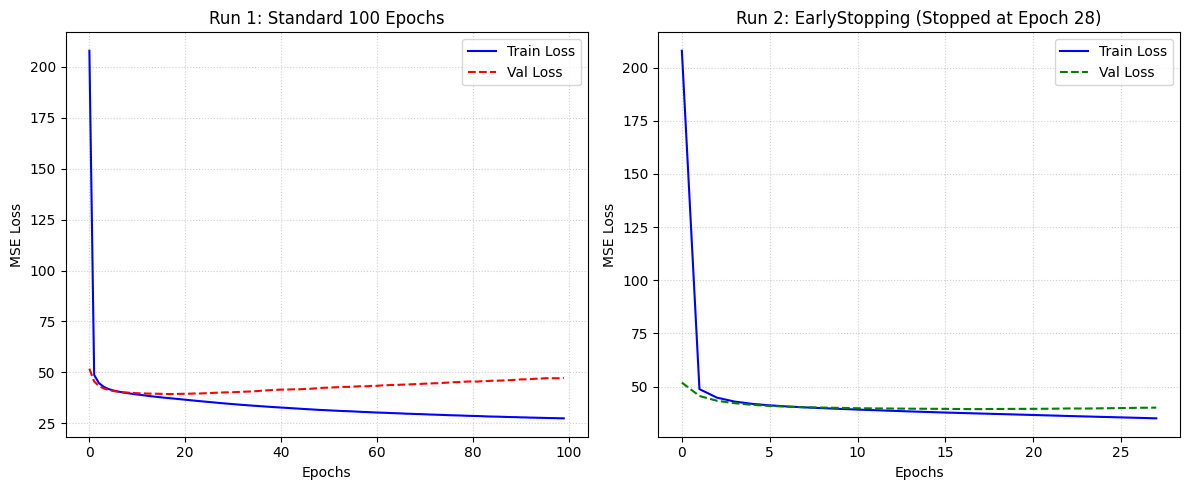

In [9]:
#Plot the diagrams

#Generated by GEMINI for proper formatting and clean visuals

plt.figure(figsize=(12, 5))

# Plot 1: 100 Epoch Run (Overfitting Demo)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
plt.title('Run 1: Standard 100 Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: EarlyStopping Run
plt.subplot(1, 2, 2)
plt.plot(history_es.history['loss'], label='Train Loss', color='blue')
plt.plot(history_es.history['val_loss'], label='Val Loss', color='green', linestyle='--')
plt.title(f'Run 2: EarlyStopping (Stopped at Epoch {len(history_es.history["loss"])})')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(
    os.path.join(project_folder, "models", "MLP", "mlp_training_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [10]:
# Calculate the loss for validation set

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

preds_100 = MLP.predict(X_val).flatten()
mse_100 = mean_squared_error(y_val, preds_100)
rmse_100 = np.sqrt(mse_100)
mae_100 = mean_absolute_error(y_val, preds_100)
r2_100 = r2_score(y_val, preds_100)

preds_es = MLP_es.predict(X_val).flatten()
mse_es = mean_squared_error(y_val, preds_es)
rmse_es = np.sqrt(mse_es)
mae_es = mean_absolute_error(y_val, preds_es)
r2_es = r2_score(y_val, preds_es)

print("--- MLP Validation Set Results (Epochs: 100)---")
print("==================================================")
print(f"MSE  : {mse_100:.4f}")
print(f"RMSE : {rmse_100:.4f}")
print(f"MAE  : {mae_100:.4f}")
print(f"R^2  : {r2_100:.4f}")
print("==================================================")

print("--- MLP Validation Set Results with Early Stopping---")
print("==================================================")
print(f"MSE  : {mse_es:.4f}")
print(f"RMSE : {rmse_es:.4f}")
print(f"MAE  : {mae_es:.4f}")
print(f"R^2  : {r2_es:.4f}")
print("==================================================")

114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- MLP Validation Set Results (Epochs: 100)---
MSE  : 47.2807
RMSE : 6.8761
MAE  : 5.3364
R^2  : 0.6199
--- MLP Validation Set Results with Early Stopping---
MSE  : 39.3762
RMSE : 6.2750
MAE  : 4.8679
R^2  : 0.6835


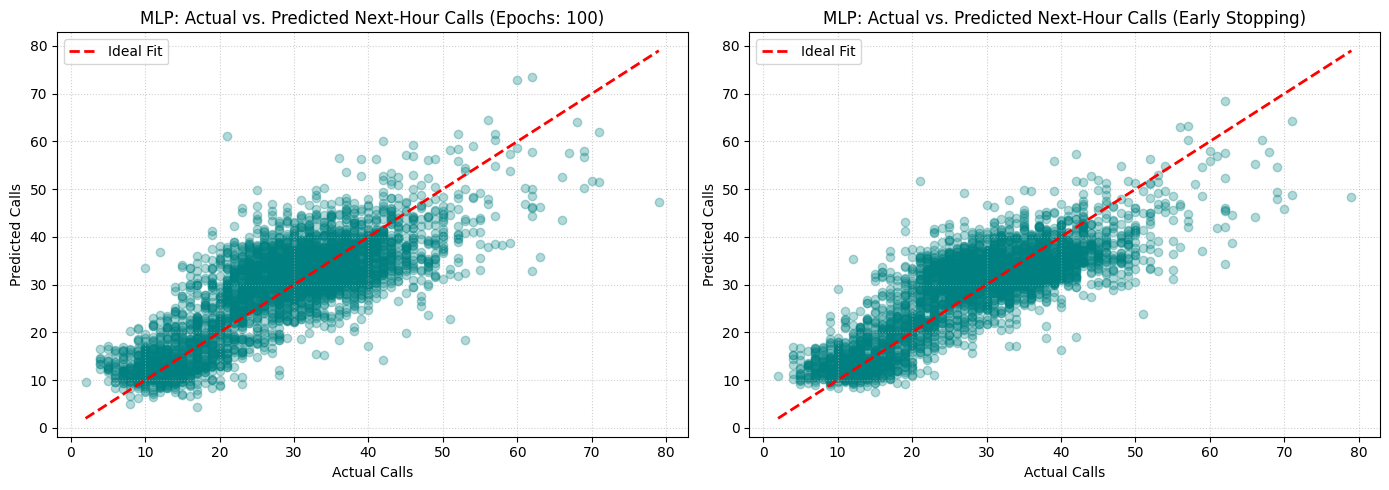

In [11]:
#Generated by GEMINI for proper formatting and clean visuals

# Predicted vs. Actual Diagnostic Plot (Validation Set)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_val, preds_100, alpha=0.3, color='teal')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('MLP: Actual vs. Predicted Next-Hour Calls (Epochs: 100)')
plt.xlabel('Actual Calls')
plt.ylabel('Predicted Calls')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.scatter(y_val, preds_es, alpha=0.3, color='teal')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('MLP: Actual vs. Predicted Next-Hour Calls (Early Stopping)')
plt.xlabel('Actual Calls')
plt.ylabel('Predicted Calls')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig(
    os.path.join(project_folder, "models", "MLP", "MLP_actual_v_predicted.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [12]:
# Calculate the loss for the better model over Test Set

test_preds = MLP_es.predict(X_test).flatten()

test_mse = mean_squared_error(y_test, test_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print("==================================================")
print("      FINAL MODEL (TEST SET EVALUATION)  ")
print("==================================================")
print(f"Test MSE  : {test_mse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print(f"Test R^2  : {test_r2:.4f}")
print("==================================================")

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
      FINAL MODEL (TEST SET EVALUATION)  
Test MSE  : 79.7632
Test RMSE : 8.9310
Test MAE  : 6.2539
Test R^2  : 0.6524


In [13]:
#Sanity checks generated from GEMINI to verify whats causing such a high error for test
# The test data has a higher variance for the call volume over what has been trained
# While the Validation Max calls is 79 per hour, test set has instances for 166 per hour

# Check target distribution differences between Val and Test
print(f"Val  - Mean: {y_val.mean():.2f}, Max: {y_val.max()}, Std: {y_val.std():.2f}")
print(f"Test - Mean: {y_test.mean():.2f}, Max: {y_test.max()}, Std: {y_test.std():.2f}")

# Check largest prediction errors on the test set
test_residuals = np.abs(y_test - test_preds)
print(f"Max single error on Test set: {test_residuals.max():.2f} calls")
print(f"95th percentile error on Test set: {np.percentile(test_residuals, 95):.2f} calls")

Val  - Mean: 28.20, Max: 79, Std: 11.16
Test - Mean: 31.82, Max: 166, Std: 15.15
Max single error on Test set: 61.15 calls
95th percentile error on Test set: 18.28 calls


In [14]:
# Save the models and history for future reference

MLP.save(os.path.join(project_folder, "models", "MLP", "mlp_model_epoch100.keras"))
MLP_es.save(os.path.join(project_folder, "models", "MLP", "mlp_model_es.keras"))

df_history_100 = pd.DataFrame(history.history)

df_history_100.index = df_history_100.index + 1
df_history_100.index.name = 'epoch'

csv_path = os.path.join(project_folder, "models", "MLP", "mlp_history_100.csv")
df_history_100.to_csv(csv_path)

df_history_es = pd.DataFrame(history_es.history)

df_history_es.index = df_history_es.index + 1
df_history_es.index.name = 'epoch'

csv_path_es = os.path.join(project_folder, "models", "MLP", "mlp_history_es.csv")
df_history_es.to_csv(csv_path_es)

#LSTM

In [15]:
#import the required libraries for LSTM training
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [16]:
# Create a function to generate sequential data based on the time_step
def create_sequences(X_data, y_data, time_steps=6):
    X_seq, y_seq = [], []
    X_vals = X_data.values
    y_vals = y_data.values

    for index in range(len(X_vals) - time_steps):
        X_seq.append(X_vals[index : index + time_steps])
        y_seq.append(y_vals[index + time_steps])

    return np.array(X_seq), np.array(y_seq)

In [17]:
# Create a function to build the LSTM Model for easy looping over time_steps
def build_LSTM_model(time_steps, num_features, seed=SEED):

  # Clear the backend for a clean start each time
  tf.keras.backend.clear_session()
  tf.random.set_seed(42)

  model = Sequential([
      LSTM(64, input_shape=(time_steps, num_features), return_sequences=False),
      Dropout(0.2),
      Dense(32, activation='relu'),
      Dense(1, activation='linear')
  ])
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

  return model

In [18]:
time_steps = [2,4,6,12,24,48]  #Past hours to look at

#Dictionaries to save all the models and its data
model_lstm_dict = {}
history_lstm_dict = {}
val_preds = {}
val_mse = {}
val_mae = {}
val_r2  = {}
stopped_epoch = {}

In [19]:
# Train the model for each of the time_step

for time_step in time_steps:
  # generate sequential data for each time_step
  X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_step)
  X_val_seq, y_val_seq = create_sequences(X_val, y_val, time_step)
  X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_step)

  print(f"Time Step: {time_step}")
  print(f"X_train 3D shape: {X_train_seq.shape} | y_train shape: {y_train_seq.shape}")
  print(f"X_val 3D shape  : {X_val_seq.shape}   | y_val shape  : {y_val_seq.shape}")
  print(f"X_test 3D shape  : {X_test_seq.shape}   | y_test shape  : {y_test_seq.shape}")

  #resetting keras for a clean start (backup)
  tf.keras.backend.clear_session()
  tf.random.set_seed(42)

  #build the model
  model_lstm_dict[time_step] = build_LSTM_model(time_step, X_train.shape[1])

  #train the model
  history_lstm_dict[time_step] = model_lstm_dict[time_step].fit(
    X_train_seq,
    y_train_seq,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
  )

  # Calculate data for Validation Test
  val_preds[time_step] = model_lstm_dict[time_step].predict(X_val_seq, verbose=0).flatten()
  val_mse[time_step] = mean_squared_error(y_val_seq, val_preds[time_step])
  val_mae[time_step] = mean_absolute_error(y_val_seq, val_preds[time_step])
  val_r2[time_step]  = r2_score(y_val_seq, val_preds[time_step])
  stopped_epoch[time_step] = len(history.history['loss'])

  # Save the model and history for future reference
  model_filename = f"lstm_model_timestep_{time_step}.keras"
  model_lstm_dict[time_step].save(os.path.join(project_folder, "models", "LSTM", model_filename))

  df_history = pd.DataFrame(history_lstm_dict[time_step].history)
  df_history.index = df_history.index + 1
  df_history.index.name = 'epoch'

  history_filename = f"lstm_history_timestep_{time_step}.csv"
  csv_path = os.path.join(project_folder, "models", "LSTM", history_filename)
  df_history.to_csv(csv_path)

Time Step: 2
X_train 3D shape: (14828, 2, 48) | y_train shape: (14828,)
X_val 3D shape  : (3622, 2, 48)   | y_val shape  : (3622,)
X_test 3D shape  : (2780, 2, 48)   | y_test shape  : (2780,)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


464/464 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 244.8283 - mean_absolute_error: 11.0949 - val_loss: 50.5467 - val_mean_absolute_error: 5.4981
Epoch 2/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 56.6713 - mean_absolute_error: 5.7321 - val_loss: 45.1513 - val_mean_absolute_error: 5.1979
Epoch 3/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 53.1542 - mean_absolute_error: 5.5730 - val_loss: 43.5363 - val_mean_absolute_error: 5.1252
Epoch 4/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 51.2881 - mean_absolute_error: 5.4532 - val_loss: 42.5306 - val_mean_absolute_error: 5.0515
Epoch 5/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 49.6659 - mean_absolute_error: 5.3769 - val_loss: 42.2427 - val_mean_absolute_error: 5.0369
Epoch 6/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 48.6370 - mean_absolute_error: 5.3281 - val_loss: 41.6016 - val_mean_absolute_error: 4.9995
Epoch 7/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 47.6536 - mean_absolute_error: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


464/464 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 180.6045 - mean_absolute_error: 9.1599 - val_loss: 47.8491 - val_mean_absolute_error: 5.3815
Epoch 2/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 53.0696 - mean_absolute_error: 5.5487 - val_loss: 44.9669 - val_mean_absolute_error: 5.2165
Epoch 3/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 49.8350 - mean_absolute_error: 5.4039 - val_loss: 43.8074 - val_mean_absolute_error: 5.1680
Epoch 4/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 47.9984 - mean_absolute_error: 5.2988 - val_loss: 43.6194 - val_mean_absolute_error: 5.1692
Epoch 5/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 47.3585 - mean_absolute_error: 5.2741 - val_loss: 43.0955 - val_mean_absolute_error: 5.1365
Epoch 6/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 45.7227 - mean_absolute_error: 5.1837 - val_loss: 43.5840 - val_mean_absolute_error: 5.1767
Epoch 7/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 44.9198 - mean_absolute_error: 5

...

Epoch 1/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 181.0257 - mean_absolute_error: 9.2477 - val_loss: 47.4658 - val_mean_absolute_error: 5.2727
Epoch 2/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 53.0996 - mean_absolute_error: 5.5311 - val_loss: 44.1888 - val_mean_absolute_error: 5.1001
Epoch 3/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 50.5284 - mean_absolute_error: 5.4154 - val_loss: 43.1727 - val_mean_absolute_error: 5.0404
Epoch 4/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 48.7662 - mean_absolute_error: 5.3373 - val_loss: 42.1512 - val_mean_absolute_error: 5.0113
Epoch 5/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 47.2121 - mean_absolute_error: 5.2627 - val_loss: 41.7055 - val_mean_absolute_error: 4.9684
Epoch 6/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 45.7832 - mean_absolute_error: 5.1915 - val_loss: 41.0602 - val_mean_absolute_error: 4.9151
Epoch 7/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 44.9544 - mean_

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 173.2992 - mean_absolute_error: 9.1016 - val_loss: 47.8353 - val_mean_absolute_error: 5.3052
Epoch 2/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 53.7658 - mean_absolute_error: 5.5581 - val_loss: 44.4025 - val_mean_absolute_error: 5.1093
Epoch 3/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 50.9590 - mean_absolute_error: 5.4152 - val_loss: 42.6807 - val_mean_absolute_error: 4.9941
Epoch 4/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 49.6270 - mean_absolute_error: 5.3708 - val_loss: 43.0466 - val_mean_absolute_error: 5.0775
Epoch 5/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 48.5818 - mean_absolute_error: 5.3364 - val_loss: 42.3710 - val_mean_absolute_error: 4.9933
Epoch 6/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 47.3839 - mean_absolute_error: 5.2715 - val_loss: 41.5372 - val_mean_absolute_error: 4.9573
Epoch 7/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 45.8797 - m

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
462/462 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 175.3982 - mean_absolute_error: 9.2691 - val_loss: 51.8073 - val_mean_absolute_error: 5.5266
Epoch 2/100
462/462 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - loss: 56.8975 - mean_absolute_error: 5.7245 - val_loss: 46.7888 - val_mean_absolute_error: 5.2357
Epoch 3/100
462/462 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 53.8111 - mean_absolute_error: 5.5840 - val_loss: 44.9495 - val_mean_absolute_error: 5.1474
Epoch 4/100
462/462 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 52.3551 - mean_absolute_error: 5.5198 - val_loss: 43.2328 - val_mean_absolute_error: 5.0592
Epoch 5/100
462/462 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 50.1516 - mean_absolute_error: 5.4196 - val_loss: 42.4712 - val_mean_absolute_error: 5.0151
Epoch 6/100
462/462 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 49.6598 - mean_absolute_error: 5.3870 - val_loss: 42.7870 - val_mean_absolute_error: 5.0634
Epoch 7/100
462/462 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 48.873

In [20]:
# Print all the validation results at once

for time_step in time_steps:
  lstm_val_preds = val_preds[time_step]
  print("--- LSTM Validation Set Results ---")
  print("==================================================")
  print(f"Time Step: {time_step}")
  print(f"Stopped Epoch: {stopped_epoch[time_step]}")
  print(f"MSE  : {val_mse[time_step]:.4f}")
  print(f"MAE  : {val_mae[time_step]:.4f}")
  print(f"R^2  : {val_r2[time_step]:.4f}\n")
  print("==================================================")

--- LSTM Validation Set Results ---
Time Step: 2
Stopped Epoch: 100
MSE  : 41.5956
MAE  : 5.0005
R^2  : 0.6657

--- LSTM Validation Set Results ---
Time Step: 4
Stopped Epoch: 100
MSE  : 42.5058
MAE  : 5.1128
R^2  : 0.6584

--- LSTM Validation Set Results ---
Time Step: 6
Stopped Epoch: 100
MSE  : 40.3334
MAE  : 4.9329
R^2  : 0.6755

--- LSTM Validation Set Results ---
Time Step: 12
Stopped Epoch: 100
MSE  : 40.8014
MAE  : 4.8899
R^2  : 0.6719

--- LSTM Validation Set Results ---
Time Step: 24
Stopped Epoch: 100
MSE  : 40.2324
MAE  : 4.8810
R^2  : 0.6761

--- LSTM Validation Set Results ---
Time Step: 48
Stopped Epoch: 100
MSE  : 41.0202
MAE  : 4.9364
R^2  : 0.6699



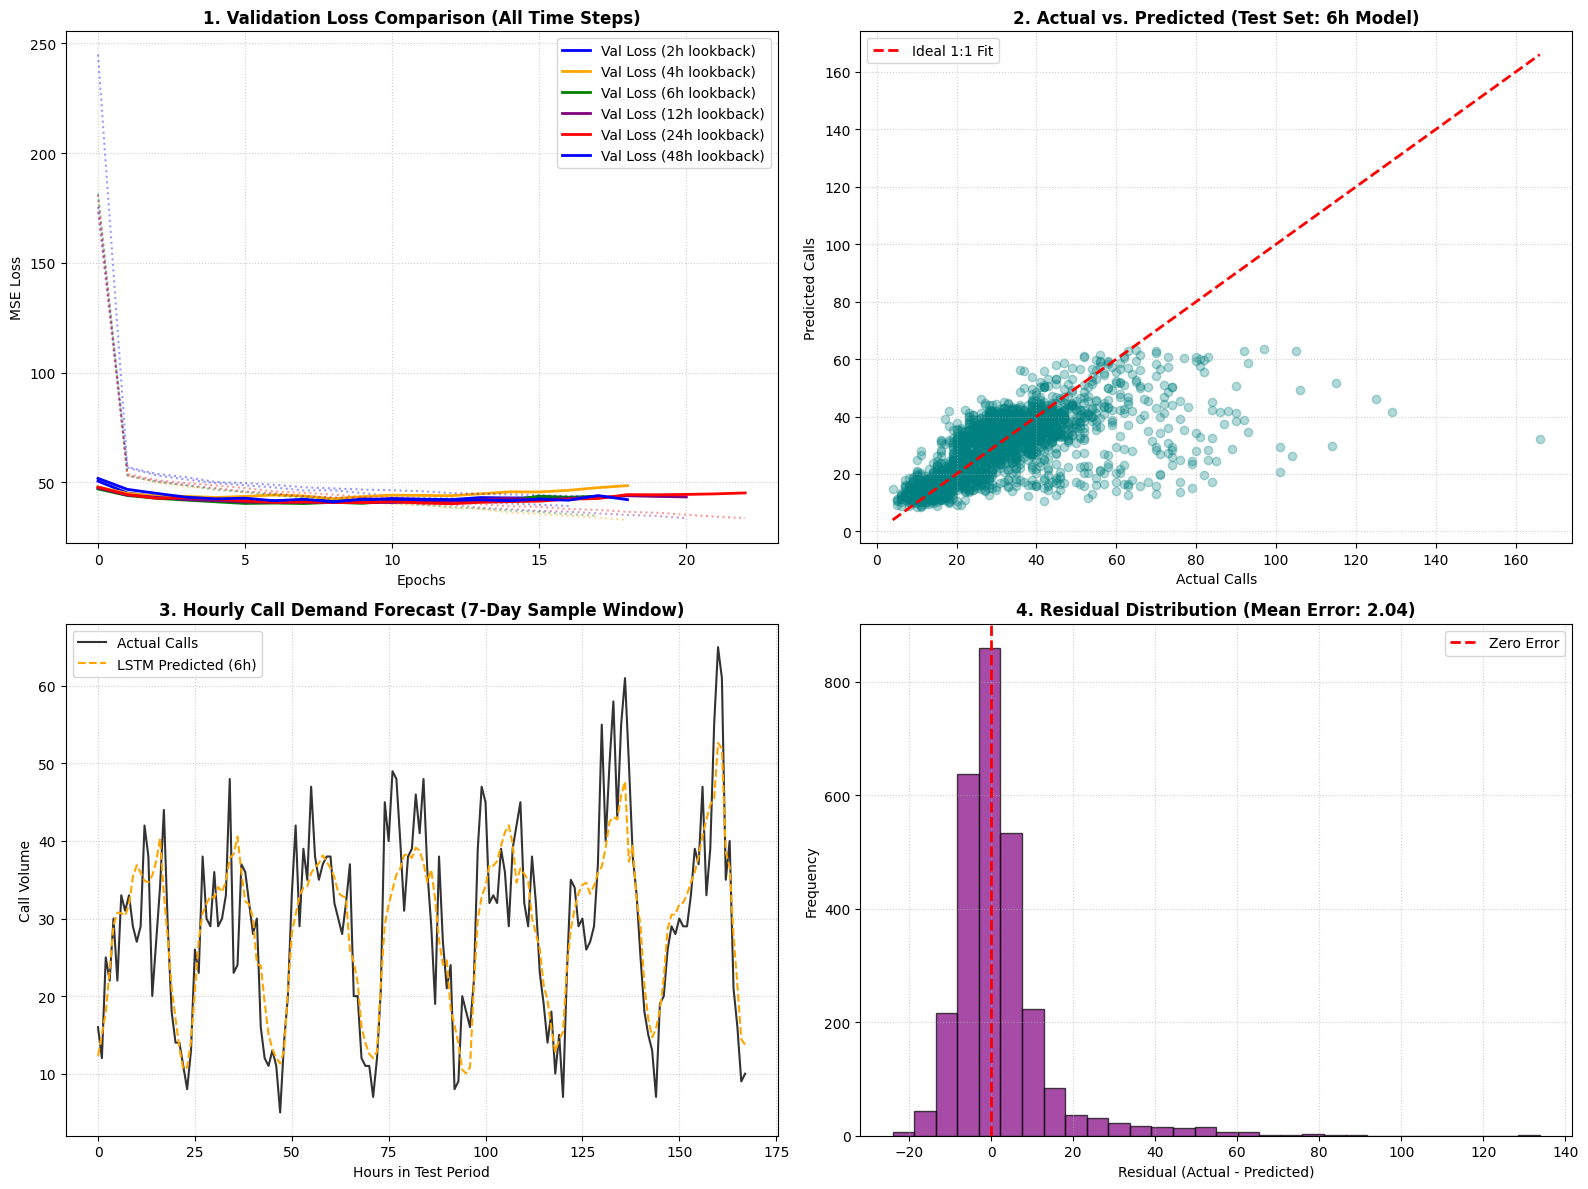


Combined diagnostic chart successfully saved to: /content/drive/MyDrive/CS171_Police_Call_Project/models/LSTM/lstm_combined_diagnostics.png


In [21]:
#Generated by GEMINI for proper formatting and clean visuals

import os
import numpy as np
import matplotlib.pyplot as plt

# Ensure output directory exists
plots_dir = os.path.join(project_folder, "models", "LSTM")
os.makedirs(plots_dir, exist_ok=True)

# Select best performing time step for test set evaluation (e.g., 24 or dynamically selected)
best_ts = 6  # Change to your winning lookback window if different

# Re-create test sequences for the chosen best model
X_t_seq, y_t_seq = create_sequences(X_test, y_test, best_ts)
best_model = model_lstm_dict[best_ts]

# Generate predictions and residuals
lstm_test_preds = best_model.predict(X_t_seq, verbose=0).flatten()
residuals = y_t_seq - lstm_test_preds

# Create 2x2 grid
plt.figure(figsize=(16, 12))

# ------------------------------------------------------------------------------
# PLOT 1: Combined Training vs. Validation Loss Curves (All Models)
# ------------------------------------------------------------------------------
plt.subplot(2, 2, 1)
colors = ['blue', 'orange', 'green', 'purple', 'red']

for idx, ts in enumerate(time_steps):
    hist = history_lstm_dict[ts].history
    color = colors[idx % len(colors)]
    plt.plot(hist['val_loss'], label=f'Val Loss ({ts}h lookback)', color=color, linewidth=2)
    plt.plot(hist['loss'], color=color, linestyle=':', alpha=0.4) # Faded train line

plt.title('1. Validation Loss Comparison (All Time Steps)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# PLOT 2: Actual vs. Predicted Scatter Plot (Best Model)
# ------------------------------------------------------------------------------
plt.subplot(2, 2, 2)
plt.scatter(y_t_seq, lstm_test_preds, alpha=0.3, color='teal')
plt.plot([y_t_seq.min(), y_t_seq.max()], [y_t_seq.min(), y_t_seq.max()], 'r--', lw=2, label='Ideal 1:1 Fit')
plt.title(f'2. Actual vs. Predicted (Test Set: {best_ts}h Model)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Calls')
plt.ylabel('Predicted Calls')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# PLOT 3: 7-Day Time-Series Horizon (First 168 Hours of Test Set)
# ------------------------------------------------------------------------------
plt.subplot(2, 2, 3)
time_window = 168  # 7 days * 24 hours
plt.plot(range(time_window), y_t_seq[:time_window], label='Actual Calls', color='black', alpha=0.8, lw=1.5)
plt.plot(range(time_window), lstm_test_preds[:time_window], label=f'LSTM Predicted ({best_ts}h)', color='orange', linestyle='--', lw=1.5)
plt.title('3. Hourly Call Demand Forecast (7-Day Sample Window)', fontsize=12, fontweight='bold')
plt.xlabel('Hours in Test Period')
plt.ylabel('Call Volume')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# PLOT 4: Residuals (Errors) Distribution
# ------------------------------------------------------------------------------
plt.subplot(2, 2, 4)
plt.hist(residuals, bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
plt.title(f'4. Residual Distribution (Mean Error: {residuals.mean():.2f})', fontsize=12, fontweight='bold')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Save combined figure
combined_plot_path = os.path.join(plots_dir, 'lstm_combined_diagnostics.png')
plt.savefig(combined_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCombined diagnostic chart successfully saved to: {combined_plot_path}")